<a href="https://colab.research.google.com/github/Tatutina/COVID-19_Project/blob/code/COVID19_%D0%9C%D0%B0%D1%88%D0%B8%D0%BD%D0%BD%D0%BE%D0%B5_%D0%BE%D0%B1%D1%83%D1%87%D0%B5%D0%BD%D0%B8%D0%B5_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Машинное обучение

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu, ttest_ind, shapiro

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn import metrics
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    confusion_matrix, multilabel_confusion_matrix, f1_score, roc_auc_score,
    roc_curve, average_precision_score, precision_recall_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression    # Импорт модели логистической регрессии
from sklearn.neighbors import KNeighborsClassifier     # Импорт классификатора K-ближайших соседей
from sklearn.tree import DecisionTreeClassifier        # Импорт классификатора на основе дерева решений
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn import metrics      # Импорт всего модуля metrics для работы с метриками оценки моделей
from sklearn.metrics import  (    # Импорт конкретных функций оценки из подмодуля metrics
    accuracy_score,              # Импорт функции для оценки точности (accuracy) модели, т.е. доли правильно предсказанных примеров
    balanced_accuracy_score,     # Импорт функции для оценки сбалансированной точности, учитывающей классовую неоднородность
    precision_score,             # Импорт функции для вычисления точности (precision)
    recall_score,                # Импорт функции для вычисления полноты (recall)
    confusion_matrix,            # Импорт функции для создания матрицы ошибок (confusion matrix):TN, TP, FN, FP
    multilabel_confusion_matrix, # Импорт функции для создания матрицы ошибок для случаев с многомерной классификацией
    f1_score,                    # Импорт функции для вычисления F1-меры
    roc_auc_score,               # Импорт функции для вычисления AUC-ROC (площадь под кривой приемлемости и ошибок)
    roc_curve,                   # Импорт функции для вычисления координат для построения ROC-кривой
    average_precision_score,     # Импорт функции для вычисления средней точности (average precision)
    precision_recall_curve       # Импорт функции для вычисления и визуализации кривой "точность-полнота" (precision-recall curve)
)

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/COVID19_Project/data/03_scaled_ml_ready.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 44 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             70000 non-null  float64
 1   hospitalized                    70000 non-null  float64
 2   icu_admission                   70000 non-null  float64
 3   ventilator_support              70000 non-null  float64
 4   days_to_recovery                70000 non-null  float64
 5   recovered                       70000 non-null  float64
 6   death                           70000 non-null  float64
 7   tests_conducted                 70000 non-null  float64
 8   gender_Male                     70000 non-null  float64
 9   comorbidities_Cancer            70000 non-null  float64
 10  comorbidities_Diabetes          70000 non-null  float64
 11  comorbidities_Heart Disease     70000 non-null  float64
 12  comorbidities_Hypertension      

In [ ]:
df.head()

,age,hospitalized,icu_admission,ventilator_support,days_to_recovery,recovered,death,tests_conducted,gender_Male,comorbidities_Cancer,...,variant_Omicron,treatment_given_1_Oxygen,treatment_given_1_Paracetamol,treatment_given_1_Remdesivir,treatment_given_1_Steroids,treatment_given_2_ Oxygen,treatment_given_2_ Paracetamol,treatment_given_2_ Remdesivir,treatment_given_2_ Steroids,test_type_PCR
0,1.539345,-1.222088,0.420437,0.232367,0.063825,-0.556339,0.556317,-1.418596,-0.994245,-0.711627,...,0.998886,-0.503257,-0.498705,-0.501517,-0.500848,-0.334628,-0.331797,-0.333386,-0.332672,0.997717
1,1.435541,-1.222088,0.420437,0.232367,-1.134677,-0.556339,0.556317,-0.004293,-0.994245,-0.711627,...,0.998886,-0.503257,-0.498705,1.993949,-0.500848,-0.334628,-0.331797,-0.333386,-0.332672,0.997717
2,0.951122,-1.222088,-2.378478,-4.303528,1.262327,-0.556339,0.556317,-0.711445,-0.994245,1.405231,...,0.998886,-0.503257,-0.498705,-0.501517,-0.500848,2.988392,-0.331797,-0.333386,-0.332672,-1.002288
3,-0.502136,0.818272,0.420437,0.232367,0.995993,1.797466,0.556317,-0.711445,-0.994245,1.405231,...,0.998886,-0.503257,-0.498705,-0.501517,-0.500848,-0.334628,-0.331797,-0.333386,-0.332672,0.997717
4,1.677751,0.818272,0.420437,0.232367,-0.069342,-0.556339,-1.797538,0.702858,1.005788,-0.711627,...,0.998886,1.987057,-0.498705,-0.501517,-0.500848,-0.334628,-0.331797,-0.333386,3.005968,0.997717


* Разобьём датасет на данные для обучения и тестирования методом **train_test_split** библиотеки **Scikit-learn**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df.drop("death", axis=1),
    df["death"],
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=df["death"]
)

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((56000, 43), (14000, 43), (56000,), (14000,))

## Метрики качества для задач классификации: точность и специфичность, F1, ROC AUC, PR AUC

In [ ]:
def calculate_specificity(true_labels, predictions):
    conf_matrix = confusion_matrix(true_labels, predictions)
    tn, fp, fn, tp = conf_matrix.ravel()
    specif = (tn / (tn + fp)).round(4)
    return specif, (tn, fp, fn, tp)

In [ ]:
  def get_all_metrics(
    true_labels,
    predictions,
    probabilities,
    print_metrics=False,
    **kwargs
):

    kwargs_roc_auc = dict()

    probabilities = probabilities[:, 1]


    accuracy = accuracy_score(true_labels, predictions)
    balanced_accuracy=balanced_accuracy_score(true_labels, predictions)
    precision = precision_score(true_labels, predictions)
    recall = recall_score(true_labels, predictions)
    f1 = f1_score(true_labels, predictions)

    roc_auc = roc_auc_score(true_labels, probabilities,**kwargs_roc_auc)
    pr_auc = average_precision_score(true_labels, predictions)

    specificity, conf_matrix = calculate_specificity(true_labels, predictions)


    tn, fp, fn, tp = conf_matrix

    print(
            "Accuracy = {:.4f}\nBalanced_accuracy = {:.4f}\nPrecision = {:.4f}\nRecall = {:.4f}\nF1_score = {:.4f}\nROC AUC = {:.4f}\nPR AUC = {:.4f}\nSpecificity = {:.4f}".format(
                accuracy, balanced_accuracy, precision, recall, f1, roc_auc, pr_auc, specificity
            )
        )


    return {
        "Accuracy": accuracy,
        "Balanced accuracy": balanced_accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1_score": f1,
        "ROC AUC": roc_auc,
        "PR AUC": pr_auc,
        "Specificity": specificity
    }

In [ ]:
def model_train_test(X_train, y_train, X_test, y_test, model, **kwargs):

    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)

    if isinstance(model, LogisticRegression):
        importance = model.coef_[0]
    elif isinstance(model, DecisionTreeClassifier):
        importance = model.feature_importances_
    else:
         importance = None

    print(str(model), end="\n\n")

    all_metrics = get_all_metrics(
        y_test,
        pred,
        proba,
        print_metrics=True,
        **kwargs,
    )
    return pred, proba, importance, all_metrics

## Сравнение алгоритмов  

In [36]:
def model_train_test(X_train, y_train, X_test, y_test, model):
    """Обучает модель и возвращает предсказания + метрики"""
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba) if y_proba is not None else None
    }

    importance = (getattr(model, 'coef_', None) or
                  getattr(model, 'feature_importances_', None))

    print(f"✅ {model.__class__.__name__}: Accuracy = {metrics['accuracy']:.3f}")
    print(classification_report(y_test, y_pred))

    return y_pred, y_proba, importance, metrics

# 3. ПОДГОТОВКА ДАННЫХ (если еще не сделано)
if 'fast_recovery' not in df.columns:
    median_days = df['days_to_recovery'].median()
    df['fast_recovery'] = (df['days_to_recovery'] <= median_days).astype(int)

# Признаки и цель
exclude_cols = ['fast_recovery', 'cluster', 'recovered', 'days_to_recovery']
X = df.select_dtypes(include=[np.number]).drop(columns=[col for col in exclude_cols if col in df.columns])
y = df['fast_recovery']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("✅ Данные готовы!")
print(f"Train классы: {np.bincount(y_train)}")
print(f"Test классы: {np.bincount(y_test)}")

✅ Данные готовы!
Train классы: [25902 30098]
Test классы: [6476 7524]


In [39]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import numpy as np
import pandas as pd

def model_train_test(X_train, y_train, X_test, y_test, model):
    """Исправленная версия - работает с coef_ и feature_importances_"""
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Предсказанные вероятности (если есть)
    y_proba = None
    if hasattr(model, 'predict_proba'):
        try:
            y_proba = model.predict_proba(X_test)[:, 1]
        except:
            y_proba = None

    # Метрики
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred)
    }

    if y_proba is not None:
        metrics['roc_auc'] = roc_auc_score(y_test, y_proba)

    print(f"\n📊 {model.__class__.__name__}")
    print(f"   Accuracy: {metrics['accuracy']:.3f}")
    if 'roc_auc' in metrics:
        print(f"   ROC-AUC:  {metrics['roc_auc']:.3f}")
    print(classification_report(y_test, y_pred))

    # ✅ ИСПРАВЛЕНИЕ: Правильная обработка importance
    importance = None
    if hasattr(model, 'coef_'):
        importance = model.coef_[0] if len(model.coef_.shape) > 1 else model.coef_
    elif hasattr(model, 'feature_importances_'):
        importance = model.feature_importances_

    return y_pred, y_proba, importance, metrics


In [40]:
# ✅ ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ
pred_logreg, proba_logreg, importance_logreg, all_metrics_logreg = model_train_test(
    X_train, y_train,        # ❌ НЕ y_train.values!
    X_test, y_test,
    LogisticRegression(random_state=42, max_iter=1000)
)

# ✅ ДЕРЕВО РЕШЕНИЙ
pred_dt, proba_dt, importance_dt, all_metrics_dt = model_train_test(
    X_train, y_train,
    X_test, y_test,
    DecisionTreeClassifier(random_state=42, max_depth=5)
)

# ✅ KNN
pred_knn, proba_knn, importance_knn, all_metrics_knn = model_train_test(
    X_train, y_train,
    X_test, y_test,
    KNeighborsClassifier(n_neighbors=5)
)

print("\n🎉 ВСЕ МОДЕЛИ ОБУЧЕНЫ!")



📊 LogisticRegression
   Accuracy: 0.538
   ROC-AUC:  0.498
              precision    recall  f1-score   support

           0       0.54      0.00      0.01      6476
           1       0.54      1.00      0.70      7524

    accuracy                           0.54     14000
   macro avg       0.54      0.50      0.35     14000
weighted avg       0.54      0.54      0.38     14000


📊 DecisionTreeClassifier
   Accuracy: 0.535
   ROC-AUC:  0.495
              precision    recall  f1-score   support

           0       0.43      0.02      0.03      6476
           1       0.54      0.98      0.69      7524

    accuracy                           0.53     14000
   macro avg       0.48      0.50      0.36     14000
weighted avg       0.49      0.53      0.39     14000


📊 KNeighborsClassifier
   Accuracy: 0.501
   ROC-AUC:  0.494
              precision    recall  f1-score   support

           0       0.46      0.42      0.44      6476
           1       0.53      0.57      0.55      75

## Матрицы ошибок

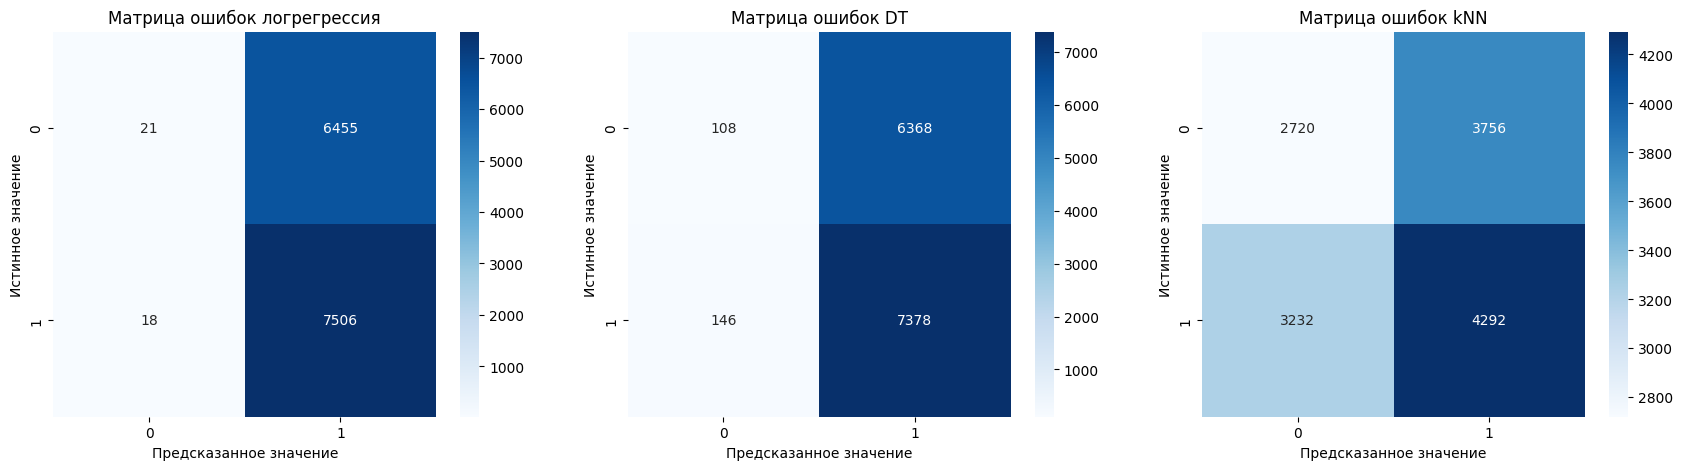

In [41]:
#Строим матрицу ошибок для модели
confus_matrix = metrics.confusion_matrix(y_test, pred_logreg)
confus_matrix1 = metrics.confusion_matrix(y_test, pred_dt)
confus_matrix2 = metrics.confusion_matrix(y_test, pred_knn)

fig, axes = plt.subplots(1, 3, figsize=(21, 5))
sns.heatmap(confus_matrix, annot=True, fmt='', cmap='Blues', ax=axes[0])
axes[0].set_title('Матрица ошибок логрегрессия')
axes[0].set_xlabel('Предсказанное значение')
axes[0].set_ylabel('Истинное значение')

sns.heatmap(confus_matrix1, annot=True, fmt='', cmap='Blues', ax=axes[1])
axes[1].set_title('Матрица ошибок DT')
axes[1].set_xlabel('Предсказанное значение')
axes[1].set_ylabel('Истинное значение')

sns.heatmap(confus_matrix2, annot=True, fmt='', cmap='Blues', ax=axes[2])
axes[2].set_title('Матрица ошибок kNN')
axes[2].set_xlabel('Предсказанное значение')
axes[2].set_ylabel('Истинное значение');

In [42]:
def plot_roc_pr_curves(true_labels, algorithms):

    fig, ax = plt.subplots(1, 2, figsize=(20, 8))
    ax[0].set_title("ROC-кривая", fontsize=20)
    ax[1].set_title("PR-кривая", fontsize=20)

    for alg_name, probabilities in algorithms.items():
        fpr, tpr, _ = roc_curve(true_labels, probabilities[:, 1])
        precisions, recalls, _ = precision_recall_curve(true_labels, probabilities[:, 1])

        ax[0].plot(
            fpr,
            tpr,
            label="{} (ROC AUC = {})".format(
                alg_name,
                round(
                    roc_auc_score(true_labels, probabilities[:, 1]),
                    3
                )
            )
        )
        ax[1].plot(
            recalls,
            precisions,
            label="{} (PR AUC = {})".format(
                alg_name,
                round(
                    average_precision_score(true_labels, probabilities[:, 1]),
                    3
                )
            )
        )

    ax[0].legend(fontsize=14)
    ax[0].set_xlabel("Ложноположительные", fontsize=16)
    ax[0].set_ylabel("Истинно положительные", fontsize=16)

    ax[1].legend(fontsize=14)
    ax[1].set_xlabel("Recall", fontsize=16)
    ax[1].set_ylabel("Precision", fontsize=16)
    plt.show()

In [44]:
# Сравнение моделей
results_df = pd.DataFrame({
    'Accuracy': [all_metrics_logreg['accuracy'], all_metrics_dt['accuracy'], all_metrics_knn['accuracy']],
    'ROC-AUC': [all_metrics_logreg.get('roc_auc', 0),
                all_metrics_dt.get('roc_auc', 0),
                all_metrics_knn.get('roc_auc', 0)]
}, index=['LogisticRegression', 'DecisionTree', 'KNeighbors'])

print("🏆 СРАВНЕНИЕ МОДЕЛЕЙ:")
print(results_df.round(3))

# ТОП-10 важных признаков LogisticRegression
if importance_logreg is not None:
    feature_importance_df = pd.DataFrame({
        'feature': X_train.columns,
        'importance': np.abs(importance_logreg)
    }).sort_values('importance', ascending=False)

    print("\n🔥 ТОП-10 ПРИЗНАКОВ (LogisticRegression):")
    print(feature_importance_df.head(10))


🏆 СРАВНЕНИЕ МОДЕЛЕЙ:
                    Accuracy  ROC-AUC
LogisticRegression     0.538    0.498
DecisionTree           0.535    0.495
KNeighbors             0.501    0.494

🔥 ТОП-10 ПРИЗНАКОВ (LogisticRegression):
                         feature  importance
8         comorbidities_Diabetes    0.021616
32               variant_Omicron    0.019830
31                 variant_Delta    0.013382
37     treatment_given_2_ Oxygen    0.012847
22              symptoms_3_Fever    0.012046
13           symptoms_1_Headache    0.011822
12              symptoms_1_Fever    0.011468
28               severity_Severe    0.010902
35  treatment_given_1_Remdesivir    0.010866
16            symptoms_2_Fatigue    0.010792


* Сагрегируем все метрики моделей

In [45]:
ans_df = pd.DataFrame(
    [all_metrics_logreg, all_metrics_dt, all_metrics_knn],
    index=["Logistic Regression", "Decision Tree", "kNN"]
)
ans_df

,accuracy,roc_auc
Logistic Regression,0.537643,0.497986
Decision Tree,0.534714,0.495265
kNN,0.500857,0.493979


In [46]:
for metric in ans_df.columns:
    sorted_ans_df = ans_df.sort_values(by=metric, ascending=False)
    print(
        "{}:{}{}".format(
            metric,
            " " * (20 - len(metric)),
            sorted_ans_df.index.tolist()
        )
    )

accuracy:            ['Logistic Regression', 'Decision Tree', 'kNN']
roc_auc:             ['Logistic Regression', 'Decision Tree', 'kNN']


## Вклад признаков в предсказание

* Метод, который упорядочивает и визуализирует коэффициенты регрессии для каждого признака

In [48]:
def plot_imp(ssz, importance):
    order = np.argsort(importance)
    ssz = ssz[order]
    importance = importance[order]

    for idx, val in enumerate(importance):
        print(f'{ssz[idx]:40} {val:.4f}')
    plt.figure(figsize=(4, np.ceil(len(ssz) / 4)))

    plt.barh(ssz, importance)
    plt.show()

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 45 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             70000 non-null  float64
 1   hospitalized                    70000 non-null  float64
 2   icu_admission                   70000 non-null  float64
 3   ventilator_support              70000 non-null  float64
 4   days_to_recovery                70000 non-null  float64
 5   recovered                       70000 non-null  float64
 6   death                           70000 non-null  float64
 7   tests_conducted                 70000 non-null  float64
 8   gender_Male                     70000 non-null  float64
 9   comorbidities_Cancer            70000 non-null  float64
 10  comorbidities_Diabetes          70000 non-null  float64
 11  comorbidities_Heart Disease     70000 non-null  float64
 12  comorbidities_Hypertension      

In [50]:
df.drop("death", axis=1, inplace=True)

comorbidities_Cancer                     -0.0216
variant_Delta                            -0.0198
vaccination_status_Partial               -0.0134
symptoms_1_Fatigue                       -0.0115
severity_Moderate                        -0.0109
treatment_given_2_ Steroids              -0.0105
symptoms_1_Headache                      -0.0103
symptoms_2_Sore Throat                   -0.0096
gender_Male                              -0.0090
comorbidities_Heart Disease              -0.0088
tests_conducted                          -0.0085
symptoms_2_Headache                      -0.0072
symptoms_2_Fever                         -0.0053
ventilator_support                       -0.0051
treatment_given_2_ Paracetamol           -0.0049
symptoms_2_Fatigue                       -0.0047
symptoms_3_Headache                      -0.0045
treatment_given_1_Oxygen                 -0.0011
symptoms_3_Loss of Smell                 -0.0010
symptoms_3_Fever                         -0.0008
hospitalized        

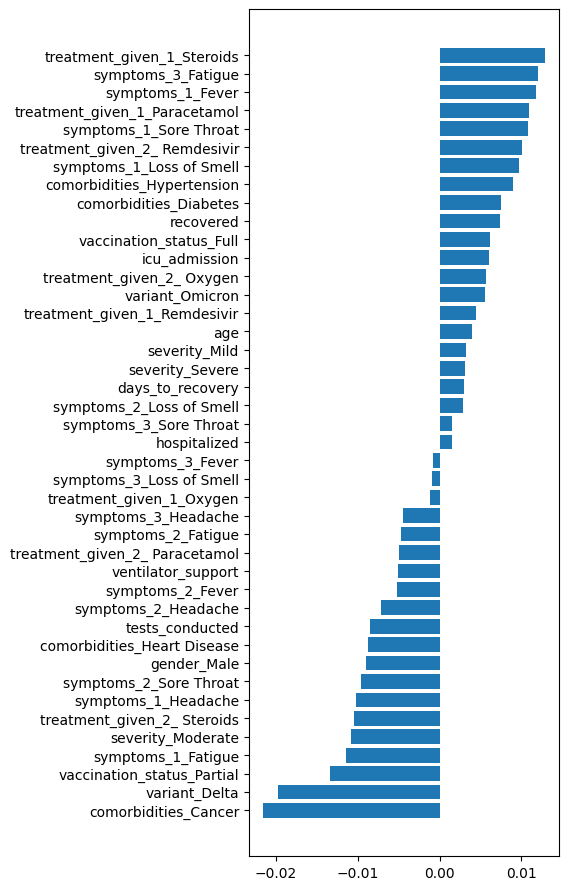

In [51]:
ssz = df.columns
plot_imp(ssz, importance_logreg)

* Выведем абсолютный вклад признаков в предсказание

symptoms_3_Fever                         0.0008
symptoms_3_Loss of Smell                 0.0010
treatment_given_1_Oxygen                 0.0011
hospitalized                             0.0015
symptoms_3_Sore Throat                   0.0015
symptoms_2_Loss of Smell                 0.0028
days_to_recovery                         0.0030
severity_Severe                          0.0031
severity_Mild                            0.0032
age                                      0.0039
treatment_given_1_Remdesivir             0.0045
symptoms_3_Headache                      0.0045
symptoms_2_Fatigue                       0.0047
treatment_given_2_ Paracetamol           0.0049
ventilator_support                       0.0051
symptoms_2_Fever                         0.0053
variant_Omicron                          0.0055
treatment_given_2_ Oxygen                0.0057
icu_admission                            0.0060
vaccination_status_Full                  0.0062
symptoms_2_Headache                     

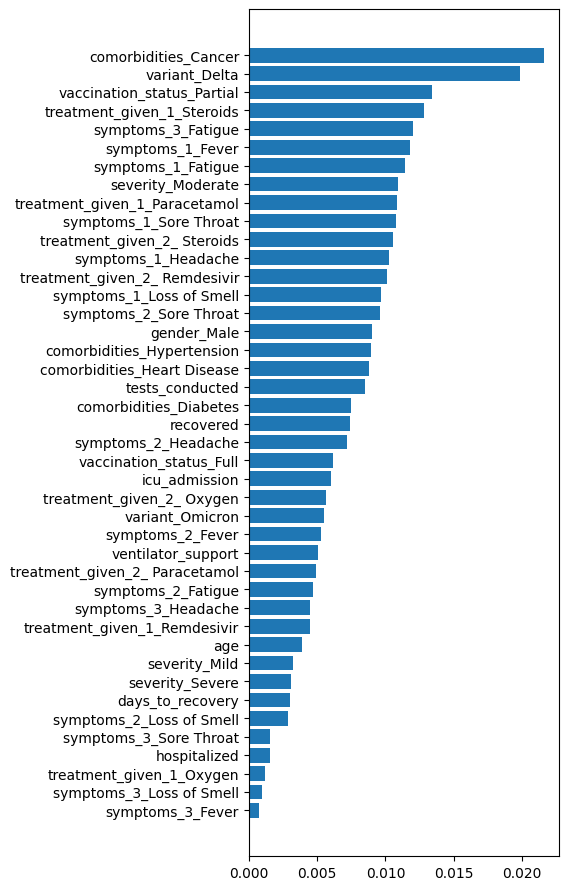

In [52]:
plot_imp(ssz, np.abs(importance_logreg))

Важность признаков, полученная с помощью Деревьев решений

ventilator_support                       0.0000
days_to_recovery                         0.0000
tests_conducted                          0.0000
comorbidities_Hypertension               0.0000
symptoms_1_Loss of Smell                 0.0000
symptoms_1_Headache                      0.0000
comorbidities_Heart Disease              0.0000
symptoms_2_Headache                      0.0000
symptoms_3_Sore Throat                   0.0000
vaccination_status_Full                  0.0000
severity_Severe                          0.0000
severity_Moderate                        0.0000
symptoms_2_Loss of Smell                 0.0000
symptoms_2_Sore Throat                   0.0000
symptoms_3_Fever                         0.0000
variant_Delta                            0.0000
treatment_given_1_Paracetamol            0.0000
treatment_given_2_ Paracetamol           0.0000
treatment_given_2_ Oxygen                0.0000
treatment_given_1_Remdesivir             0.0000
variant_Omicron                         

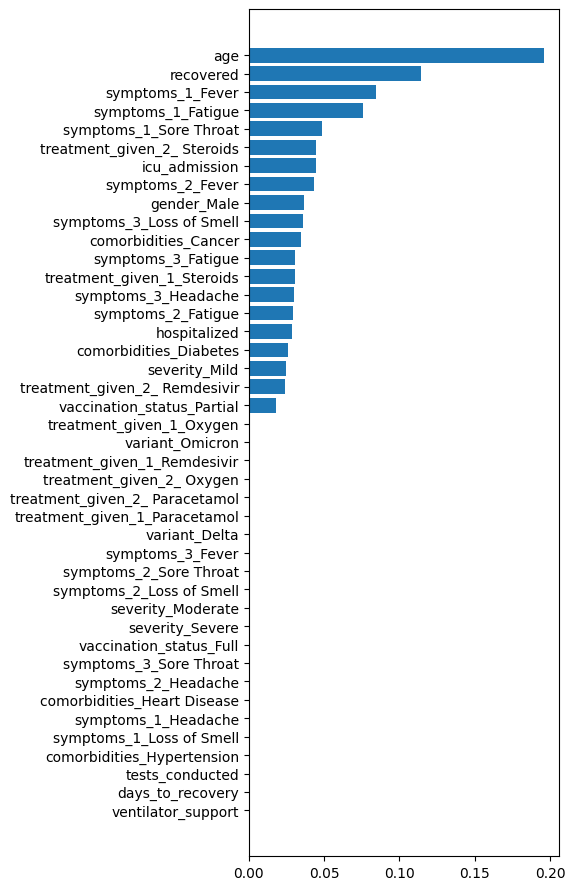

In [53]:
plot_imp(ssz, importance_dt)



---

